In [2]:
from datasets import load_dataset
dataset = load_dataset("SetFit/ag_news")

c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd

train_df = pd.DataFrame(dataset["train"])
train_df.head()


,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


In [4]:
test_df = pd.DataFrame(dataset["test"])
test_df

,text,label,label_text
0,Fears for T N pension after talks Unions repre...,2,Business
1,The Race is On: Second Private Team Sets Launc...,3,Sci/Tech
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3,Sci/Tech
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3,Sci/Tech
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3,Sci/Tech
...,...,...,...
7595,Around the world Ukrainian presidential candid...,0,World
7596,Void is filled with Clement With the supply of...,1,Sports
7597,Martinez leaves bitter Like Roger Clemens did ...,1,Sports
7598,5 of arthritis patients in Singapore take Bext...,2,Business


In [5]:
train_df.count()

text          120000
label         120000
label_text    120000
dtype: int64

In [6]:
train_df.columns

Index(['text', 'label', 'label_text'], dtype='object')

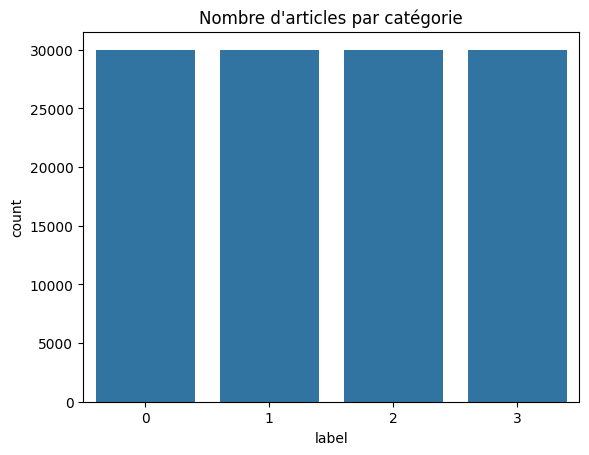

['Security Further Tightened In Jammu JAMMU, IHK : Nov 19 (SADA) - In occupied Kashmir, security apparatus has been further beefed up in the winter capital Jammu with additional deployment of police and para military personnel ahead of Indian Prime Minister Manmohan Singh #39;s arrival here ', 'Hurricanes fail to dampen economy The US economy continued to grow in the early fall despite being buffeted by rising energy costs and hurricanes, the Federal Reserve said yesterday, providing its last snapshot of business conditions before Election Day.', 'In Dallas, Knicks See Big Man They Wanted Erick Dampier got everything he wanted this summer: money, security, a shot at a championship. The Knicks wanted Dampier this summer, but instead, they got a heavy dose of disappointment.', 'Euro soars as ECB chief defends rate THE dollar tumbled to new lows against the euro yesterday as markets brushed aside an upgrade to US growth and a fresh warning from the European Central Banks President ', 'Suc

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="label", data=train_df)
plt.title("Nombre d'articles par catégorie")
plt.show()
print(train_df["text"].sample(5).tolist())


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")
nltk.download("punkt")

stpw = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  
    text = re.sub(r"[^a-z\s]", " ", text)  
    tokens = text.split()
    tokens = [t for t in tokens if t not in stpw]
    return " ".join(tokens)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aamir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aamir\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [9]:

train_df["clean_text"] = train_df["text"].apply(clean_text)
train_df = train_df.drop_duplicates(subset=["clean_text"])

test_df["clean_text"] = test_df["text"].apply(clean_text)
test_df = test_df.drop_duplicates(subset=["clean_text"])

train_df.head()


,text,label,label_text,clean_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business,wall st bears claw back black reuters reuters ...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business,oil economy cloud stocks outlook reuters reute...
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business,iraq halts oil exports main southern pipeline ...
4,"Oil prices soar to all-time record, posing new...",2,Business,oil prices soar time record posing new menace ...


In [13]:
from sentence_transformers import SentenceTransformer

# Modèle mono anglais très performant (mpnet)
model = SentenceTransformer("all-mpnet-base-v2")

# Encoder les textes
train_embeddings = model.encode(train_df["clean_text"].tolist(), show_progress_bar=True)
test_embeddings = model.encode(test_df["clean_text"].tolist(), show_progress_bar=True)


c:\Users\aamir\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aamir\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  " your disk. This warning can be disabled by setting the"


RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-693829a6-421f880f4c5fd9ba09500462;14d38f02-202d-4fbd-b559-2e29333d9092)

Entry Not Found for url: https://huggingface.co/api/models/sentence-transformers/all-mpnet-base-v2/tree/main/additional_chat_templates?recursive=false&expand=false.
additional_chat_templates does not exist on "main"